📌 Dataset inicial


,cliente_id,edad,ingresos,ciudad
0,1,25.0,50000.0,Buenos Aires
1,2,30.0,60000.0,buenos aires
2,3,NaN,55000.0,CABA
3,4,22.0,NaN,Cordoba
4,5,40.0,70000.0,Córdoba
5,5,40.0,70000.0,Córdoba
6,6,35.0,65000.0,None
7,7,28.0,NaN,Rosario
8,8,200.0,1000000.0,Rosario
9,9,32.0,62000.0,rosario



📊 Información general
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   cliente_id  11 non-null     int64  
 1   edad        9 non-null      float64
 2   ingresos    9 non-null      float64
 3   ciudad      10 non-null     object 
dtypes: float64(2), int64(1), object(1)
memory usage: 484.0+ bytes

📊 Estadísticas descriptivas


,cliente_id,edad,ingresos
count,11.000000,9.000000,9.000000
mean,5.454545,50.222222,165555.555556
std,2.876235,56.503933,312985.667048
min,1.000000,22.000000,50000.000000
25%,3.500000,28.000000,58000.000000
50%,5.000000,32.000000,62000.000000
75%,7.500000,40.000000,70000.000000
max,10.000000,200.000000,1000000.000000



❗ Valores nulos por columna
cliente_id    0
edad          2
ingresos      2
ciudad        1
dtype: int64

🔁 Cantidad de duplicados
1

🧹 Dataset limpio


,cliente_id,edad,ingresos,ciudad
0,1,25.0,50000.0,buenos aires
1,2,30.0,60000.0,buenos aires
2,3,31.0,55000.0,caba
3,4,22.0,177500.0,cordoba
4,5,40.0,70000.0,córdoba
6,6,35.0,65000.0,None
7,7,28.0,177500.0,rosario
8,8,200.0,1000000.0,rosario
9,9,32.0,62000.0,rosario
10,10,31.0,58000.0,mendoza


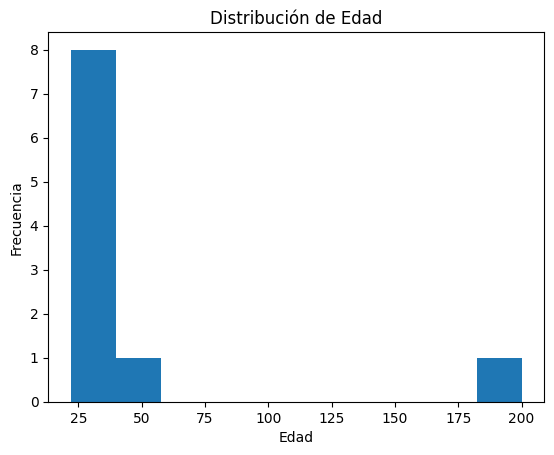

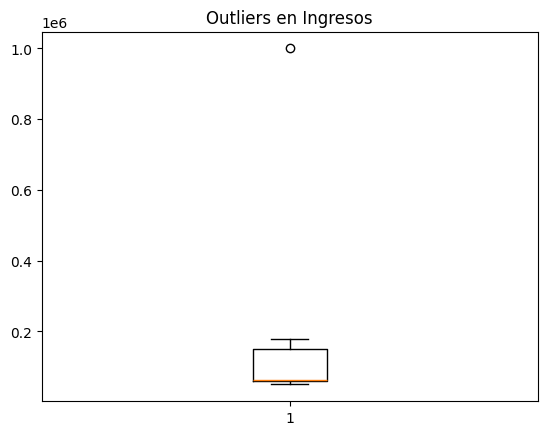

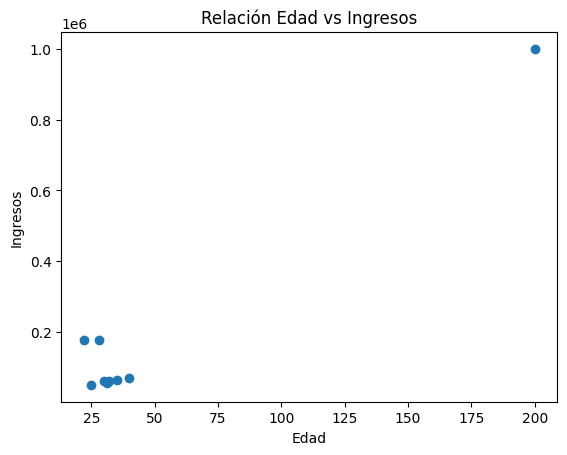


🚨 Posibles outliers en edad


,cliente_id,edad,ingresos,ciudad
8,8,200.0,1000000.0,rosario



🚨 Posibles outliers en ingresos


,cliente_id,edad,ingresos,ciudad
8,8,200.0,1000000.0,rosario



💡 Preguntas para reflexionar:
- ¿Qué problemas de calidad encontraste?
- ¿Cómo impactan en el análisis?
- ¿Qué otras mejoras propondrías?



In [1]:
# ==========================================
# PRÁCTICA ACTIVIDAD ASINCRÓNICA
# PROFILADO Y EDA
# ==========================================

# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CREACIÓN DEL DATASET
# ==========================================

data = {
    "cliente_id": [1,2,3,4,5,5,6,7,8,9,10],
    "edad": [25, 30, np.nan, 22, 40, 40, 35, 28, 200, 32, np.nan],
    "ingresos": [50000, 60000, 55000, None, 70000, 70000, 65000, None, 1000000, 62000, 58000],
    "ciudad": ["Buenos Aires", "buenos aires", "CABA", "Cordoba", "Córdoba", "Córdoba", None, "Rosario", "Rosario", "rosario", "Mendoza"]
}

df = pd.DataFrame(data)

print("📌 Dataset inicial")
display(df)

# ==========================================
# 2. PROFILADO DE DATOS
# ==========================================

print("\n📊 Información general")
df.info()

print("\n📊 Estadísticas descriptivas")
display(df.describe())

print("\n❗ Valores nulos por columna")
print(df.isnull().sum())

print("\n🔁 Cantidad de duplicados")
print(df.duplicated().sum())

# ==========================================
# 3. LIMPIEZA DE DATOS
# ==========================================

# Eliminar duplicados
df = df.drop_duplicates()

# Imputación
df["edad"] = df["edad"].fillna(df["edad"].median())
df["ingresos"] = df["ingresos"].fillna(df["ingresos"].mean())

# Normalización de texto
df["ciudad"] = df["ciudad"].str.lower().str.strip()

print("\n🧹 Dataset limpio")
display(df)

# ==========================================
# 4. ANÁLISIS EXPLORATORIO (EDA)
# ==========================================

# Histograma
plt.figure()
plt.hist(df["edad"])
plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

# Boxplot
plt.figure()
plt.boxplot(df["ingresos"])
plt.title("Outliers en Ingresos")
plt.show()

# Scatter plot
plt.figure()
plt.scatter(df["edad"], df["ingresos"])
plt.title("Relación Edad vs Ingresos")
plt.xlabel("Edad")
plt.ylabel("Ingresos")
plt.show()

# ==========================================
# 5. DETECCIÓN DE OUTLIERS
# ==========================================

print("\n🚨 Posibles outliers en edad")
display(df[df["edad"] > 100])

print("\n🚨 Posibles outliers en ingresos")
display(df[df["ingresos"] > 200000])

# ==========================================
# 6. REFLEXIÓN (para el alumno)
# ==========================================

print("""
💡 Preguntas para reflexionar:
- ¿Qué problemas de calidad encontraste?
- ¿Cómo impactan en el análisis?
- ¿Qué otras mejoras propondrías?
""")